<a href="https://colab.research.google.com/github/huamanchristian44/LAB10/blob/develop/Laboratorio_10_Mineria_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Laboratorio 10: Clustering**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.stats import zscore

In [ ]:
# Cargar el archivo
df = pd.read_csv('/content/drive/MyDrive/vehículos.csv')

In [ ]:
# Eliminar columnas especificadas
cols_eliminar = ['fabricante', 'modelo', 'transmision', 'traccion', 'clase', 'combustible', 'consumo']
df.drop(columns=cols_eliminar, inplace=True)

In [ ]:
#Guardar la variable clase_tipo
df_target = df['clase_tipo'].copy()
df.drop(columns=['clase_tipo'], inplace=True)

In [ ]:
# Imputación de datos faltantes
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

<ipython-input-40-0319f42123ab>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
<ipython-input-40-0319f42123ab>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [ ]:
# Outliers univariados: método IQR
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

In [ ]:
# Outliers multivariado: Z-score
z_scores = np.abs(zscore(df.select_dtypes(include=['float64', 'int64'])))
df = df[(z_scores < 3).all(axis=1)]

In [ ]:
# Guardar índice después del filtrado
indices_validos = df.index

In [ ]:
# Resetear df
df = df.reset_index(drop=True)

In [ ]:
# Aplicar el mismo filtrado a df_target
df_target = df_target.loc[indices_validos].reset_index(drop=True)

In [ ]:
#   Escalado y transformaciones
df_dummies = pd.get_dummies(df, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_dummies)

Aplicando K-means

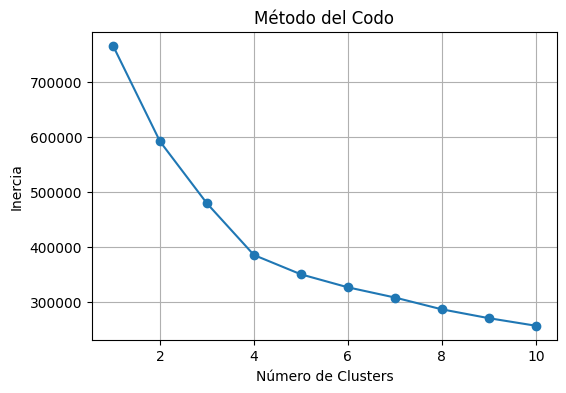

In [ ]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

In [ ]:
k_optimo = 4
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_clusters = df.copy()
df_clusters['cluster'] = clusters

In [ ]:
#Analisis de clusters
print(df_clusters.groupby('cluster').mean(numeric_only=True))

                year  desplazamiento  cilindros         co2  \
cluster                                                       
0        2001.869542        2.555547   4.735286  406.611991   
1        1998.912035        4.961171   7.480617  610.263924   
2        2003.345519        1.925034   4.043054  329.963881   
3        1999.976370        3.396883   5.909357  486.051538   

         consumo_litros_milla  
cluster                        
0                    0.173014  
1                    0.258106  
2                    0.140229  
3                    0.206766  


Evaluacion interna

In [ ]:
print("\nEvaluación Interna:")
print("Silhouette Score:", round(silhouette_score(X_scaled, clusters), 3))
print("Calinski-Harabasz:", round(calinski_harabasz_score(X_scaled, clusters), 3))
print("Davies-Bouldin:", round(davies_bouldin_score(X_scaled, clusters), 3))


Evaluación Interna:
Silhouette Score: 0.312
Calinski-Harabasz: 11487.657
Davies-Bouldin: 1.369


Evaluacion externa

In [ ]:
kmeans_8 = KMeans(n_clusters=8, random_state=42, n_init=10)
clusters_8 = kmeans_8.fit_predict(X_scaled)

In [ ]:
#Indice coincidiente con df_target
df_target = df_target.reset_index(drop=True)

print("\nEvaluación Externa con clase_tipo y 8 clusters:")
print("Adjusted Rand Index:", round(adjusted_rand_score(df_target, clusters_8), 3))
print("Normalized Mutual Information:", round(normalized_mutual_info_score(df_target, clusters_8), 3))


Evaluación Externa con clase_tipo y 8 clusters:
Adjusted Rand Index: 0.093
Normalized Mutual Information: 0.14
